# Exercise: Picking Time

**Module 6: Correlation Analysis** | Lean Six Sigma Data Analytics

---

## The Scenario

Imagine you work at a warehouse where several items are collected to complete an order.

- **CTQ (Y variable):** Picking time — the total processing time to collect all items of an order
- **Influence factor (X variable):** Number of items per order

**Question:** Suppose you want to complete an order before 4 o'clock (16:00). At what time should the employee start picking at the latest?

In [1]:
# Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm

sns.set_style('whitegrid')

DATA_FILE = '../data/da-lss.xlsx'
xlsx = pd.ExcelFile(DATA_FILE)

print('Ready for picking time analysis!')

Ready for picking time analysis!


In [2]:
def load_picking():
    """Load picking data: Order, Items, Pick-time"""
    df = pd.read_excel(xlsx, sheet_name='Picking', skiprows=7, header=0, usecols=[0, 1, 2])
    df.columns = ['Order', 'Items', 'Pick_time']
    return df.dropna()

picking = load_picking()
print('DATA LOADED')
print('=' * 50)
print(picking.head(10))
print(f'\nTotal observations: {len(picking)}')

DATA LOADED
   Order  Items  Pick_time
0      1     18       11.6
1      2     11        9.5
2      3      7        6.0
3      4      7        4.7
4      5     22       15.0
5      6      5        7.1
6      7      9        5.4
7      8      5        9.3
8      9     11        9.0
9     10     24       17.6

Total observations: 30


---

## Step 1: Determine Variable Types

First, we have to look at what type of variables we have:

| Variable | Role | Type |
|----------|------|------|
| Pick-time | Y (response) | Numerical |
| Items | X (predictor) | Numerical |

If we look at the tree diagram, we see that **regression analysis** is a suitable technique to use.

Remember the four steps of regression analysis:
1. Fitted line plot
2. Main analysis
3. Residual analysis
4. Prediction interval

---

## Step 2: Fitted Line Plot and Main Analysis

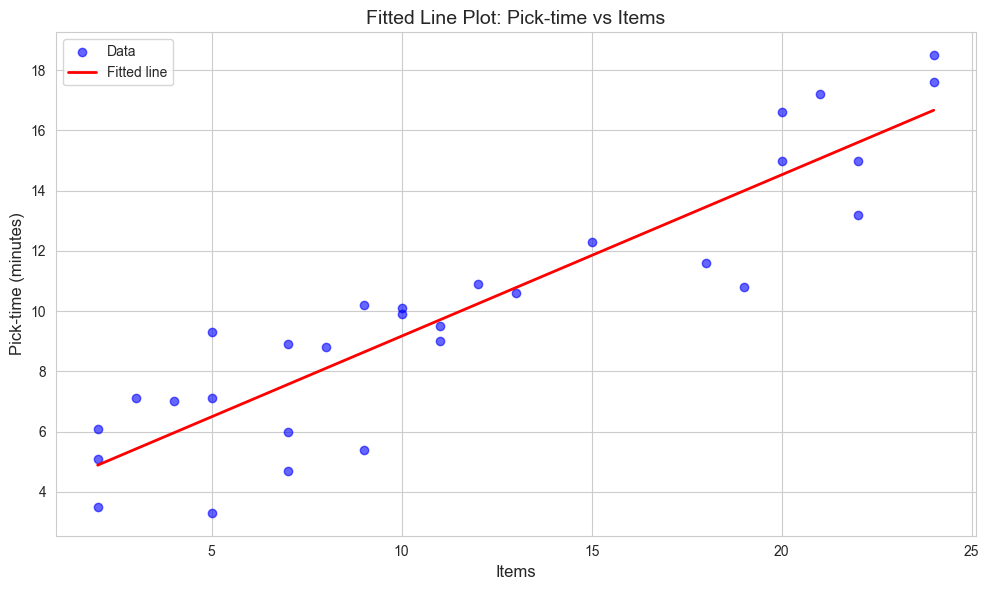

In [3]:
# Fitted Line Plot
x = picking['Items']
y = picking['Pick_time']

# Fit regression model
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

# Create fitted line plot
fig, ax = plt.subplots(figsize=(10, 6))

# Scatter plot
ax.scatter(x, y, color='blue', alpha=0.6, label='Data')

# Regression line
x_line = np.linspace(x.min(), x.max(), 100)
y_line = intercept + slope * x_line
ax.plot(x_line, y_line, color='red', linewidth=2, label='Fitted line')

ax.set_xlabel('Items', fontsize=12)
ax.set_ylabel('Pick-time (minutes)', fontsize=12)
ax.set_title('Fitted Line Plot: Pick-time vs Items', fontsize=14)
ax.legend()

plt.tight_layout()
plt.show()

In [4]:
# Main Regression Analysis
print('REGRESSION ANALYSIS')
print('=' * 50)
print(f'\nTransfer Function:')
print(f'Pick-time = {intercept:.4f} + {slope:.4f} × Items')
print(f'\nInterpretation:')
print(f'Each additional item takes an employee {slope:.2f} minutes extra.')
print(f'\nStatistical Significance:')
print(f'P-value: {p_value:.6f}')
if p_value < 0.05:
    print('The relationship between Items and Pick-time is statistically significant (p < 0.05).')
print(f'\nR-squared: {r_value**2:.4f}')
print(f'The R-squared is relatively high. The number of items is a "big fish" —')
print(f'it predicts rather accurately how long the picking time will be.')

REGRESSION ANALYSIS

Transfer Function:
Pick-time = 3.8123 + 0.5358 × Items

Interpretation:
Each additional item takes an employee 0.54 minutes extra.

Statistical Significance:
P-value: 0.000000
The relationship between Items and Pick-time is statistically significant (p < 0.05).

R-squared: 0.8312
The R-squared is relatively high. The number of items is a "big fish" —
it predicts rather accurately how long the picking time will be.


---

## Step 3: Residual Analysis

We still have to check if our conclusions remain valid after the residual analysis.

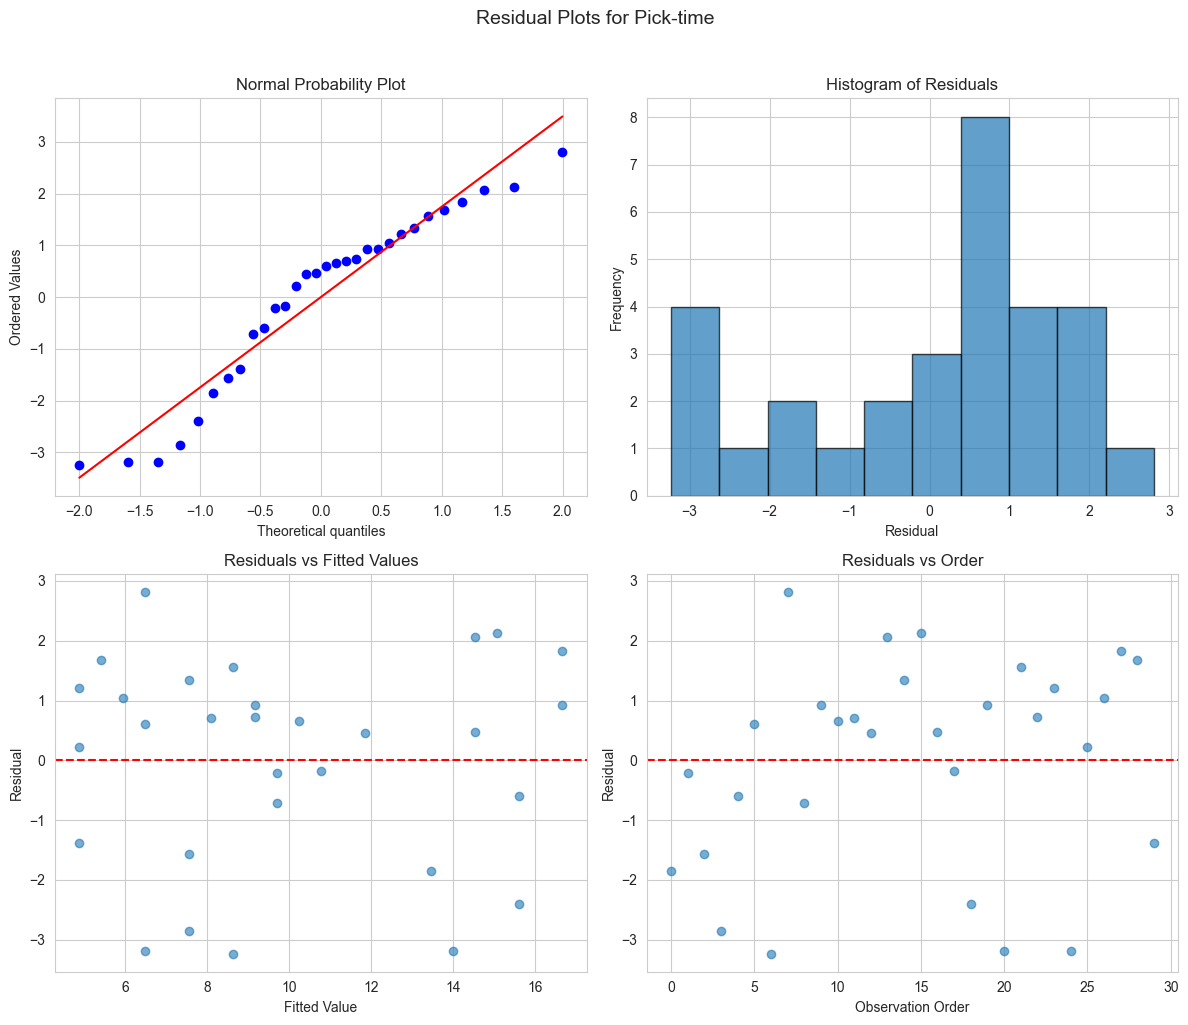

In [5]:
# Calculate residuals
y_pred = intercept + slope * x
residuals = y - y_pred

# Four-in-one residual plot
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1. Normal Probability Plot
stats.probplot(residuals, dist="norm", plot=axes[0, 0])
axes[0, 0].set_title('Normal Probability Plot')
axes[0, 0].get_lines()[0].set_markerfacecolor('blue')
axes[0, 0].get_lines()[0].set_markeredgecolor('blue')

# 2. Histogram of Residuals
axes[0, 1].hist(residuals, bins=10, edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel('Residual')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Histogram of Residuals')

# 3. Residuals vs Fitted Values
axes[1, 0].scatter(y_pred, residuals, alpha=0.6)
axes[1, 0].axhline(y=0, color='red', linestyle='--')
axes[1, 0].set_xlabel('Fitted Value')
axes[1, 0].set_ylabel('Residual')
axes[1, 0].set_title('Residuals vs Fitted Values')

# 4. Residuals vs Order
axes[1, 1].scatter(range(len(residuals)), residuals, alpha=0.6)
axes[1, 1].axhline(y=0, color='red', linestyle='--')
axes[1, 1].set_xlabel('Observation Order')
axes[1, 1].set_ylabel('Residual')
axes[1, 1].set_title('Residuals vs Order')

plt.suptitle('Residual Plots for Pick-time', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [6]:
print('RESIDUAL ANALYSIS')
print('=' * 50)
print('\n1. Normal Probability Plot:')
print('   The assumption is satisfied — points follow the line.')
print('\n2. Residuals vs Fitted Values:')
print('   No large outliers or strange patterns — assumption satisfied.')
print('\nConclusion: Our regression results remain valid.')

RESIDUAL ANALYSIS

1. Normal Probability Plot:
   The assumption is satisfied — points follow the line.

2. Residuals vs Fitted Values:
   No large outliers or strange patterns — assumption satisfied.

Conclusion: Our regression results remain valid.


---

## Step 4: Prediction Interval

Remember that the question was to determine a time to start picking. To answer this we have to calculate the prediction interval.

A prediction interval is calculated starting with the mean (the predicted line), then adding or subtracting two times the standard deviation.

If you repeat the experiment, about **95%** of the measurements will be within this prediction interval:
- 2.5% will be below
- 2.5% will be above

Or we can say that **97.5%** of the measurements will be below the upper boundary of the prediction interval.

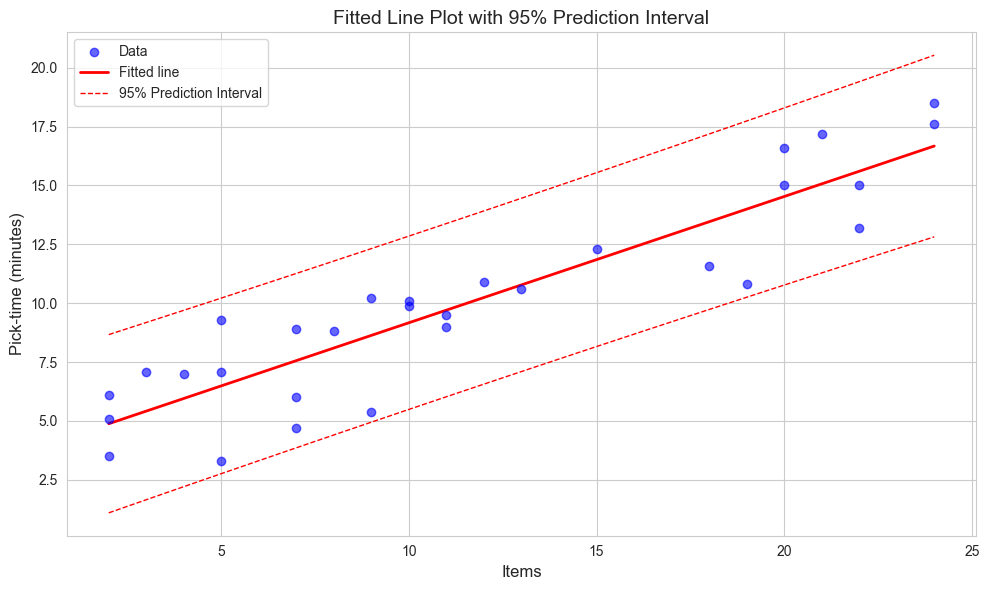

In [7]:
# Calculate prediction intervals using statsmodels
X = sm.add_constant(x)  # Add intercept
model = sm.OLS(y, X).fit()

# Create prediction range
x_pred = np.linspace(x.min(), x.max(), 100)
X_pred = sm.add_constant(x_pred)

# Get predictions with prediction intervals
predictions = model.get_prediction(X_pred)
pred_summary = predictions.summary_frame(alpha=0.05)

# Plot with prediction interval
fig, ax = plt.subplots(figsize=(10, 6))

# Scatter plot
ax.scatter(x, y, color='blue', alpha=0.6, label='Data', zorder=5)

# Regression line
ax.plot(x_pred, pred_summary['mean'], color='red', linewidth=2, label='Fitted line')

# 95% Prediction Interval (dotted lines)
ax.plot(x_pred, pred_summary['obs_ci_lower'], color='red', linestyle='--', linewidth=1, label='95% Prediction Interval')
ax.plot(x_pred, pred_summary['obs_ci_upper'], color='red', linestyle='--', linewidth=1)

ax.set_xlabel('Items', fontsize=12)
ax.set_ylabel('Pick-time (minutes)', fontsize=12)
ax.set_title('Fitted Line Plot with 95% Prediction Interval', fontsize=14)
ax.legend()

plt.tight_layout()
plt.show()

In [8]:
# Calculate prediction for 25 items
items_to_predict = 25
X_25 = np.array([[1, items_to_predict]])  # [constant, items]
pred_25 = model.get_prediction(X_25)
pred_25_summary = pred_25.summary_frame(alpha=0.05)

mean_time = pred_25_summary['mean'].values[0]
upper_bound = pred_25_summary['obs_ci_upper'].values[0]

print('PREDICTION FOR 25 ITEMS')
print('=' * 50)
print(f'\nNumber of items: {items_to_predict}')
print(f'\nAverage picking time: {mean_time:.1f} minutes')
print(f'Upper prediction interval (97.5%): {upper_bound:.1f} minutes')
print(f'\nInterpretation:')
print(f'To pick 25 items, it will take on average {mean_time:.0f} minutes.')
print(f'But average is of course not good enough.')
print(f'\nIf you want to be sure to be done on time, you have to take')
print(f'{upper_bound:.0f} minutes in your planning — then you will be done')
print(f'in 97.5% of the cases at least.')

PREDICTION FOR 25 ITEMS

Number of items: 25

Average picking time: 17.2 minutes
Upper prediction interval (97.5%): 21.1 minutes

Interpretation:
To pick 25 items, it will take on average 17 minutes.
But average is of course not good enough.

If you want to be sure to be done on time, you have to take
21 minutes in your planning — then you will be done
in 97.5% of the cases at least.


---

## Answer to the Question

In [9]:
# Calculate start time
deadline_hour = 16  # 4 o'clock = 16:00
deadline_minutes = 0
total_deadline_minutes = deadline_hour * 60 + deadline_minutes

# Latest start time (using upper prediction interval)
latest_start_minutes = total_deadline_minutes - upper_bound
start_hour = int(latest_start_minutes // 60)
start_min = int(latest_start_minutes % 60)

print('FINAL ANSWER')
print('=' * 50)
print(f'\nYou performed a regression analysis and studied the prediction interval.')
print(f'\nConclusion:')
print(f'In 97.5% of the cases, the maximum time for completing an order')
print(f'of 25 items is {upper_bound:.1f} minutes.')
print(f'\nIf you want to be done before 16:00hr,')
print(f'you have to start picking no later than {start_hour}:{start_min:02d}hr.')

FINAL ANSWER

You performed a regression analysis and studied the prediction interval.

Conclusion:
In 97.5% of the cases, the maximum time for completing an order
of 25 items is 21.1 minutes.

If you want to be done before 16:00hr,
you have to start picking no later than 15:38hr.


---

## Summary

| Step | Action | Result |
|------|--------|--------|
| 1 | Identify variable types | Y: Pick-time (numerical), X: Items (numerical) → Regression |
| 2 | Fitted line plot & main analysis | Each additional item ≈ 0.5 min extra; relationship significant (p < 0.05) |
| 3 | Residual analysis | Assumptions satisfied; results remain valid |
| 4 | Prediction interval | 97.5% upper bound for 25 items ≈ 21 minutes |

**Key Insight:** To answer planning questions, use the **upper prediction interval** (97.5%) rather than the average — this gives you a time estimate you can rely on in almost all cases.